# Politeness Intensity Representation in Gemma 2 2B

**Research question:** Does the model encode politeness as a graded, linear spectrum in its internal representations, or as discrete, unordered categories?

**Setup:**

| | |
|---|---|
| **Model** | `google/gemma-2-2b` (base, completion mode) |
| **Trait** | politeness — three levels: `negative` / `neutral` / `positive` |
| **Focal layer** | 13 (midpoint of 26 total; mid-network layers typically encode abstract semantics) |
| **Data** | machine-generated paraphrases, filtered by a blind intensity judge (`data/<timestamp>/sentences/sentences_filtered.jsonl`) |

**Core hypothesis:** If the model treats politeness as a continuous 1D scale, then the activation-space vector from `negative → neutral` centroids should be *parallel* to the vector from `neutral → positive` centroids. We test this geometrically and then quantify the degree of linearity with several complementary metrics.

## 1. Setup

Load dependencies and internal library modules:

- `common` — typed `Sample` dataclass and JSONL loading utilities
- `representations` — forward-pass helpers that extract hidden-state activations at a given layer
- `analysis` — difference vectors, cosine similarity matrix, and plotting

In [ ]:
import json
import sys
from pathlib import Path

import torch

sys.path.insert(0, str(Path("..").resolve()))  # src/notebooks/ -> src/

from lib.sentences import LEVELS, load_accepted
from lib.representations import load_representations
from lib.analysis import (
    compute_difference_vectors,
    similarity_matrix,
    plot_similarity_matrix,
    acts_by_level_from_dict,
    ordinal_linearity_metrics,
    scenario_triples,
    within_scenario_linearity_metrics,
)

### 1.1 Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `MODEL` | `google/gemma-2-2b` | Small enough to run locally; has published Gemma Scope SAEs at every layer |
| `LAYER` | `13` | Mid-network (layers 10–18 are typically where abstract semantic structure peaks) |
| `TRAIT` | `politeness` | 3-level ordinal trait; good test case for linearity since levels have a natural order |
| `ACCEPTED_JSONL` | `data/<timestamp>/sentences/sentences_filtered.jsonl` | Paraphrases that passed the blind intensity quality gate |

In [ ]:
MODEL = "google/gemma-2-2b"
LAYER = 13
TRAIT = "politeness"
POOL  = "last"                                   # token pooling; folder is f"{POOL}_token"
TIMESTAMP = "20260530_001930"                    # pinned dataset version under data/
DATA_DIR  = Path("../../data") / TIMESTAMP
ACCEPTED_JSONL = DATA_DIR / "sentences" / "sentences_filtered.jsonl"
REP_DIR  = DATA_DIR / "representations"           # extract_representations.py output (root; holds unembeddings_covariance.pt)
POOL_DIR = REP_DIR / f"{POOL}_token"              # per-pool activations subdir

## 2. Load Activations

Activations are pre-computed by `0025_extract_activations.ipynb`. Load them from `data/v2/activations/`.

In [ ]:
activations = load_representations(POOL_DIR, layer=LAYER)
levels_present = [l for l in LEVELS if l in {i for (_, i, _) in activations}]
scenarios = {s for (_, _, s) in activations}
TRAITS_CFG = [{"name": TRAIT, "intensities": levels_present}]
print(f"Loaded {len(activations)} vectors  |  layer {LAYER}  |  pool '{POOL}'  |  "
      f"levels {levels_present}  |  {len(scenarios)} scenarios")

Loaded 216 vectors  |  layer 13  |  pool 'last'  |  levels ['negative', 'neutral', 'positive']  |  72 scenarios


## 3. Geometric Analysis of the Intensity Ladder

**The linearity hypothesis:** If politeness is represented as a 1D continuous scale in activation space, moving from one level to the next should trace a *straight line*. Indeed, the direction from `negative` to `neutral` should be parallel to the direction from `neutral` to `positive`.

We test this by computing *difference vectors* between level centroids and measuring their angular alignment.

### 3.1 Difference Vectors

For each ordered pair of intensity levels, we compute:

```
d(A → B) = mean_activation(B) − mean_activation(A)
```

**Three vectors:**
- `negative → neutral`: direction of the first step up the politeness scale
- `neutral → positive`: direction of the second step
- `negative → positive`: the full-span direction (equals the sum of the two if perfectly linear)

**Norm interpretation:** larger norm = greater centroid separation. The ratio between consecutive norms indicates whether the spacing is symmetric (equal steps) or compressed at one end of the scale.

In [ ]:
diffs = compute_difference_vectors(activations, TRAITS_CFG)

for (trait, lo, hi), vec in diffs.items():
    print(f"  {trait}: {lo} -> {hi}  norm={vec.norm():.2f}")

  politeness: neutral -> positive  norm=25.89
  politeness: negative -> neutral  norm=43.33
  politeness: negative -> positive  norm=45.10


### 3.2 Cosine Similarity Between Difference Vectors

Cosine similarity measures the angular alignment between two vectors, independent of their magnitudes:

| Value | Meaning |
|-------|---------|
| `+1.0` | Identical direction → perfect linearity |
| `≈ 0.0` | Orthogonal → the two transitions point in unrelated directions |
| `−1.0` | Opposite direction → the scale reverses |

Under the linearity hypothesis off-diagonal entry for `(negative→neutral) vs (neutral→positive)` should be near +1. Moreover, the full-span vector should be the sum of the two steps and should align with both.

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

labels, matrix = similarity_matrix(diffs)

print("Cosine similarity matrix:")
header = f"{'':>25}" + "".join(f"{l:>27}" for l in labels)
print(header)
for i, li in enumerate(labels):
    row = f"{li:>25}" + "".join(f"{matrix[i, j]:>27.4f}" for j in range(len(labels)))
    print(row)

if len(labels) >= 2:
    print(
        f"\nKey number — cosine similarity {labels[0]} vs {labels[1]}: {matrix[0, 1]:.4f}"
    )
    print("  +1 = same direction (linear), -1 = opposite, ~0 = unrelated")

Cosine similarity matrix:
                         politeness:positive-neutralpoliteness:neutral-negativepoliteness:positive-negative
politeness:positive-neutral                     1.0000                    -0.2286                     0.3543
politeness:neutral-negative                    -0.2286                     1.0000                     0.8293
politeness:positive-negative                     0.3543                     0.8293                     1.0000

Key number — cosine similarity politeness:positive-neutral vs politeness:neutral-negative: -0.2286
  +1 = same direction (linear), -1 = opposite, ~0 = unrelated


### 3.3 Cosine Similarity Heatmap

Color encodes cosine similarity: red (−1) → yellow (0) → green (+1).

**How to read it:**
- The diagonal is always 1.0 (self-similarity) — ignore it.
- **Off-diagonal green** → the corresponding pair of transition directions are aligned → consistent with a linear axis.
- **Off-diagonal yellow or red** → transition directions diverge → the trait is not encoded on a single ray.

A near-zero off-diagonal would indicate that the `negative→neutral` and `neutral→positive` transitions point in largely independent directions in the dense residual stream at this layer.

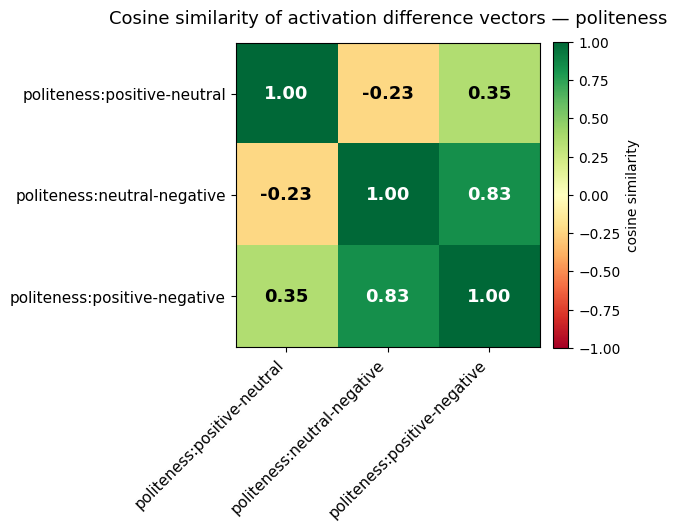

In [ ]:
n = len(labels)
cell = 2.2
fig, ax = plt.subplots(figsize=(max(6, n * cell), max(6, n * cell)))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
for i, j in itertools.product(range(n), range(n)):
    color = "white" if abs(matrix[i, j]) > 0.65 else "black"
    ax.text(
        j,
        i,
        f"{matrix[i, j]:.2f}",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=color,
    )
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("cosine similarity", fontsize=10)
ax.set_title(
    f"Cosine similarity of activation difference vectors — {TRAIT}", fontsize=13, pad=14
)
plt.tight_layout()
plt.show()

### 3.4 Layer Sweep: Direction Alignment Across Layers 8–22

The cosine similarity between difference vectors may vary by layer. This sweeps layers 8–22, re-extracting activations (using the cached multilayer pass) and recomputing the similarity matrix at each layer.

**Three curves plotted** (one per pair of transition directions):
- `positive−neutral` vs `neutral−negative` — the core linearity test
- `positive−negative` vs each partial vector — consistency of the full-span direction

**What to look for:**
- A peak or plateau in the adjacent-step curve marks the layer where the representation is most linear.
- A flat, low profile suggests no single layer organizes the trait as a 1D line.
- Consistency between the two `vs positive−negative` curves confirms the full span is well-defined.

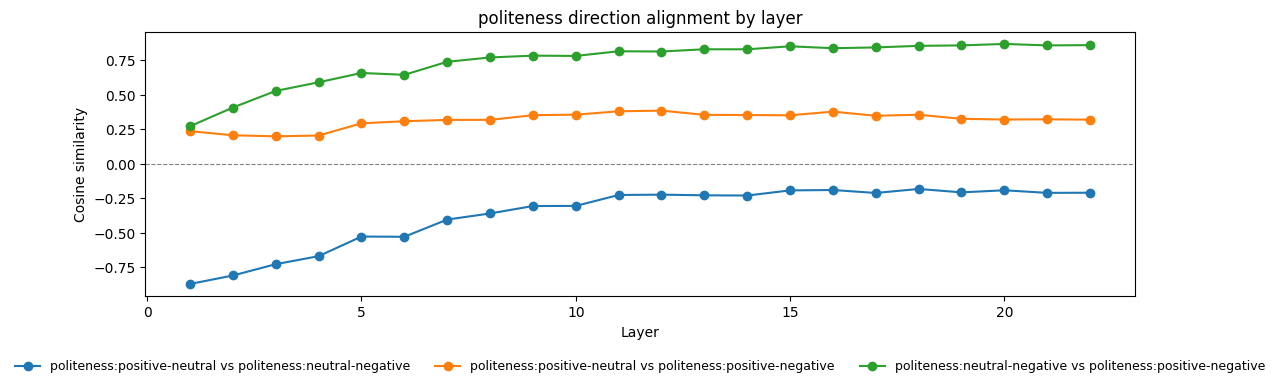

In [ ]:
sweep_layers = list(range(1, 23))

acts_all = load_representations(POOL_DIR)  # keyed by (trait, intensity, scenario_id, layer)

pair_indices = list(itertools.combinations(range(len(labels)), 2))
pair_sims = {pair: [] for pair in pair_indices}

for layer in sweep_layers:
    acts_layer = {(t, i, s): v for (t, i, s, l), v in acts_all.items() if l == layer}
    d = compute_difference_vectors(acts_layer, TRAITS_CFG)
    _, m = similarity_matrix(d)
    for pair in pair_indices:
        pair_sims[pair].append(m[pair[0], pair[1]])

fig, ax = plt.subplots(figsize=(11, 4.4))
for (i, j), sims in pair_sims.items():
    ax.plot(
        sweep_layers,
        sims,
        marker="o",
        linewidth=1.5,
        label=f"{labels[i]} vs {labels[j]}",
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title(f"{TRAIT} direction alignment by layer")
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=9
)
fig.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.28)
plt.show()

### 3.5 Metric-Aware Re-Analysis: Whitening, Anisotropy, and Disattenuation

§3.2 reports the adjacent-step cosine using the ordinary (Euclidean) dot product on the raw residual stream. That number is **not coordinate-free**: a cosine depends entirely on *which inner product* you measure it with, and the residual stream's native coordinate system is a poor choice of ruler. Here we recompute the difference-vector cosine matrix under four alternative inner products, then correct each for estimation noise.

#### Why the inner product matters

A cosine is `⟨d₁,d₂⟩ / (‖d₁‖‖d₂‖)`. The Euclidean inner product `⟨x,y⟩ = xᵀy` implicitly assumes **every one of the 2304 residual dimensions is equally important and mutually orthogonal** — neither holds for a transformer's residual stream. A general inner product is `⟨x,y⟩_M = xᵀM y` for a positive-definite `M`; equivalently, transform every vector by a *whitening matrix* `W` (with `M = WᵀW`) and take the ordinary dot product in the new coordinates. Different `W` answer different questions:

| Space | Whitening `W` | Question it answers |
|---|---|---|
| **Euclidean (raw)** | `I` | Are the steps aligned in the model's native coordinates? (the §3.2 default) |
| **Anisotropy-corrected** | `diag(1/σ)` | …after removing "rogue dimensions" — a few coordinates whose huge variance dominates every raw cosine |
| **Park causal** | `Cov(γ)^(−1/2)` | …in the inner product under which *causally independent* concepts come out orthogonal |
| **Mahalanobis / LDA** | `Σ_within^(−1/2)` | …after discounting the directions the model varies along *within* a fixed politeness level (angles measured in units of noise) |
| **Within-subj noise** | `Σ_resid^(−1/2)` | …after discounting *only the noise* — the two-way (level + scenario) residual, which (unlike Mahalanobis) does not also absorb between-scenario spread |

#### The four corrections

**1 · Anisotropy correction.** Transformer residual streams are strongly *anisotropic*: a few dimensions carry orders of magnitude more variance than the rest, and those "rogue dimensions" dominate any raw cosine (Timkey & van Schijndel, 2021). Dividing each dimension by its standard deviation — `W = diag(1/σ)`, a *diagonal* whitening, equivalent to z-scoring every coordinate — puts all dimensions on equal footing. It is the cheapest correction and the standard fix for cosine artifacts in embedding spaces.

**2 · Park causal whitening.** Park, Choe & Veitch (2024) show the residual stream has a *preferred* non-Euclidean geometry: the **causal inner product** `⟨x,y⟩_C = xᵀ Cov(γ)⁻¹ y`, where `Cov(γ)` is the covariance of the model's **unembedding vectors** (one per vocabulary token). Under it, concepts that vary independently (`French⇒English` vs `male⇒female`) come out orthogonal — making it the natural ruler for asking whether two *transitions* are aligned. We whiten by `W = Cov(γ)^(−1/2)`. *(Park's theory is stated for the unembedding/word space; `Cov(γ)^(−1/2)` is exactly the map that carries context-side representations into that frame. Applying it to a mid-layer residual is an approximation — the model also applies a final RMSNorm before unembedding — but a faithful and citable one.)*

**3 · Mahalanobis / LDA whitening.** The two whitenings above ignore the labels; this one uses them. `Σ_within` is the pooled covariance of activations **within** each politeness level — i.e. the variation that is *not* politeness, the noise. Whitening by `W = Σ_within^(−1/2)` rescales space so one unit = one standard deviation of within-level noise; a cosine here measures alignment in *discriminability* units (the geometry a linear discriminant uses). Because `Σ_within` is a 2304×2304 matrix estimated from a few hundred samples it is rank-deficient, so we regularize it with **Ledoit–Wolf shrinkage** before inverting.

**4 · Within-subjects noise whitening.** Mahalanobis (#3) removes only the level mean, so its `Σ_within` still contains the between-scenario spread — it treats that nuisance as noise. Here we instead use the **two-way residual** `Σ_resid`: from each `(level, scenario)` vector subtract *both* its level mean and its scenario mean (adding back the grand mean), leaving only the interaction + paraphrase noise. Because the *level* mean is removed from the **noise estimate** (not from the signal), the main politeness axis is preserved rather than whitened away — the principled noise covariance for this within-subjects design. As with #3 it is Ledoit–Wolf–shrunk before inversion.

#### Disattenuation — correcting for estimation noise

This step is *orthogonal* to the choice of inner product. Each step vector is a centroid difference estimated from a finite sample: `d̂ = d_true + noise`. The noise is uncorrelated between two different step vectors, so it **drags any cosine between them toward 0** — a near-orthogonal result can simply mean "too noisy to tell."

We quantify the noise with **split-half reliability**: split the scenarios in half, estimate each step vector independently on each half, and take the cosine of the two estimates of the *same* vector. A perfectly-estimated vector self-correlates at 1.0; a noisy one well below. The Spearman–Brown formula rescales the half-sample reliability `r½` to the full-sample reliability `R = 2r½ / (1 + r½)`. The **disattenuated cosine** then divides the noise back out:

> `cos_true(d₁,d₂)  ≈  cos_obs(d₁,d₂) / √(R₁ · R₂)`

If raw and disattenuated cosines agree, any observed near-orthogonality is *real*. If disattenuation lifts the cosine substantially, the raw value was partly a noise artifact and the true geometry is more linear than §3.2 suggested.

In [ ]:
# §3.5 — Build the inner-product spaces (whitening matrices)
from sklearn.covariance import LedoitWolf

D = next(iter(activations.values())).shape[0]


def inv_sqrt_psd(cov, rcond=1e-6):
    """Symmetric inverse square root M^(-1/2) of a PSD matrix.

    Eigenvalues are floored at rcond * max_eigenvalue before inversion, so a
    rank-deficient covariance still yields a finite, well-conditioned whitener.
    """
    cov = 0.5 * (cov + cov.T)
    evals, evecs = np.linalg.eigh(cov)
    evals = np.clip(evals, rcond * float(evals.max()), None)
    return (evecs * evals**-0.5) @ evecs.T


# All sample activations, float64 for numerically stable whitening.
acts_f64 = {k: v.numpy().astype(np.float64) for k, v in activations.items()}
X_all = np.stack(list(acts_f64.values()))  # (N, D)

# 1 - Euclidean: identity (reproduces §3.2).
W_eucl = np.eye(D)

# 2 - Anisotropy correction: diagonal whitening (z-score each dimension).
sigma = X_all.std(axis=0)
W_aniso = np.diag(1.0 / np.clip(sigma, 1e-8, None))

# 3 - Park causal whitening: inverse-sqrt of the unembedding covariance Cov(gamma),
# precomputed over the whole vocabulary by extract_representations.py.
cov_unembed = torch.load(REP_DIR / "unembeddings_covariance.pt", weights_only=True).numpy()
W_park = inv_sqrt_psd(cov_unembed)

# 4 - Mahalanobis / LDA whitening: inverse-sqrt of the pooled within-level covariance.
within = np.concatenate(
    [
        Xl - Xl.mean(axis=0, keepdims=True)
        for Xl in (
            np.stack([acts_f64[k] for k in acts_f64 if k[1] == lvl])
            for lvl in levels_present
        )
    ]
)
lw = LedoitWolf(assume_centered=True).fit(within)
W_lda = inv_sqrt_psd(lw.covariance_)

# 5 - Within-subjects noise whitening: inverse-sqrt of the TWO-WAY (level +
# scenario) residual covariance. Removing BOTH the level mean and the scenario
# mean leaves only the interaction + paraphrase noise — the proper "noise"
# covariance for this within-subjects design. Contrast #4, which removes only
# the level mean and so treats between-scenario spread as noise. Because
# the level mean is removed from the NOISE estimate (not from the signal), the
# main politeness axis is preserved rather than whitened away.
_tri = scenario_triples(acts_f64, levels_present, trait=TRAIT)
_M = np.stack([_tri[s] for s in sorted(_tri)])            # (S, L, D)
_resid2 = (_M - _M.mean(axis=0, keepdims=True) - _M.mean(axis=1, keepdims=True)
           + _M.mean(axis=(0, 1), keepdims=True)).reshape(-1, _M.shape[-1])
lw_within = LedoitWolf(assume_centered=True).fit(_resid2)
W_within = inv_sqrt_psd(lw_within.covariance_)

SPACES = {
    "Euclidean (raw)": W_eucl,
    "Anisotropy-corrected": W_aniso,
    "Park causal": W_park,
    "Mahalanobis / LDA": W_lda,
}
print(f"hidden dim D = {D}   samples N = {len(acts_f64)}")
print(f"Ledoit-Wolf shrinkage — within-level: {lw.shrinkage_:.4f}   within-scenario: {lw_within.shrinkage_:.4f}")
for name, W in SPACES.items():
    print(f"  {name:<22} whitener ready  (Frobenius norm = {np.linalg.norm(W):.4g})")

hidden dim D = 2304   samples N = 216
Ledoit-Wolf shrinkage — within-level: 0.1829   within-scenario: 0.2627
  Euclidean (raw)        whitener ready  (Frobenius norm = 48)
  Anisotropy-corrected   whitener ready  (Frobenius norm = 30.07)
  Park causal            whitener ready  (Frobenius norm = 34.74)
  Mahalanobis / LDA      whitener ready  (Frobenius norm = 62.64)


In [ ]:
# §3.5 — Cosine matrices and noise-disattenuated cosines in each space
N_REL_SPLITS = 300  # random scenario half-splits for the reliability estimate
REL_SEED = 0


def transform_acts(acts, W):
    """Apply whitening W to every activation vector."""
    return {k: torch.from_numpy(W @ v) for k, v in acts.items()}


def diff_dict(acts):
    """(trait, lo, hi) -> difference vector, via the §3.1 paired-scenario estimator."""
    d = compute_difference_vectors(acts, TRAITS_CFG)
    return {k: d[k].numpy() for k in d}


def cosine_matrix(vecs):
    """All-pairs cosine similarity over a list of vectors."""
    M = np.stack([v / np.linalg.norm(v) for v in vecs])
    return np.clip(M @ M.T, -1.0, 1.0)


def full_reliability(acts, canon_keys, n_splits=N_REL_SPLITS, seed=REL_SEED):
    """Spearman-Brown-corrected full-sample reliability of each step vector.

    Splits the *scenarios* randomly in half, recomputes each difference vector
    independently on each half, and averages the cosine between the two same-vector
    estimates -> half-sample reliability r_half. Spearman-Brown rescales it to
    full-sample R = 2*r_half / (1 + r_half).
    """
    rng = np.random.default_rng(seed)
    sids = list(sorted({k[2] for k in acts}))
    acc = np.zeros(len(canon_keys))
    cnt = np.zeros(len(canon_keys))
    for _ in range(n_splits):
        rng.shuffle(sids)
        cut = len(sids) // 2
        a_sids = set(sids[:cut])
        b_sids = set(sids[cut:])
        da = diff_dict({k: v for k, v in acts.items() if k[2] in a_sids})
        db = diff_dict({k: v for k, v in acts.items() if k[2] in b_sids})
        for i, key in enumerate(canon_keys):
            if key in da and key in db:
                x, y = da[key], db[key]
                acc[i] += float((x / np.linalg.norm(x)) @ (y / np.linalg.norm(y)))
                cnt[i] += 1
    r_half = acc / np.maximum(cnt, 1)
    R_full = 2.0 * r_half / (1.0 + r_half)
    return r_half, np.clip(R_full, 1e-3, 1.0)


def disattenuate(cosmat, R_full):
    """Divide each off-diagonal cosine by sqrt(R_i * R_j)."""
    R = np.sqrt(R_full)
    out = np.clip(cosmat / np.outer(R, R), -1.0, 1.0)
    np.fill_diagonal(out, 1.0)
    return out


space_results = {}
canon_keys = None
for name, W in SPACES.items():
    acts_W = transform_acts(acts_f64, W)
    dd = diff_dict(acts_W)
    if canon_keys is None:
        canon_keys = list(dd.keys())
    labels_S = [f"{hi}-{lo}" for (_, lo, hi) in canon_keys]
    cos_raw = cosine_matrix([dd[k] for k in canon_keys])
    r_half, R_full = full_reliability(acts_W, canon_keys)
    cos_dis = disattenuate(cos_raw, R_full)
    space_results[name] = dict(
        labels=labels_S, cos_raw=cos_raw, cos_dis=cos_dis, r_half=r_half, R_full=R_full
    )

# Summary table: the adjacent-step cosine (positions 0 and 1 of the matrix).
labels_S = space_results["Euclidean (raw)"]["labels"]
print(f"Adjacent-step alignment:  ({labels_S[1]})  vs  ({labels_S[0]})")
print(f"(Euclidean raw cos should reproduce the §3.2 value)\n")
hdr = f"{'space':<22}{'raw cos':>10}{'disatt cos':>13}{'R[0]':>9}{'R[1]':>9}{'R[2]':>9}"
print(hdr)
print("-" * len(hdr))
for name, r in space_results.items():
    print(
        f"{name:<22}{r['cos_raw'][0, 1]:>10.4f}{r['cos_dis'][0, 1]:>13.4f}"
        f"{r['R_full'][0]:>9.3f}{r['R_full'][1]:>9.3f}{r['R_full'][2]:>9.3f}"
    )
print(
    f"\nR[0]={labels_S[0]}   R[1]={labels_S[1]}   R[2]={labels_S[2]}"
    f"   (full-sample reliability of each step vector)"
)

Adjacent-step alignment:  (neutral-negative)  vs  (positive-neutral)
(Euclidean raw cos should reproduce the §3.2 value)

space                    raw cos   disatt cos     R[0]     R[1]     R[2]
------------------------------------------------------------------------
Euclidean (raw)          -0.2286      -0.2528    0.866    0.944    0.938
Anisotropy-corrected     -0.2029      -0.2286    0.848    0.928    0.925
Park causal              -0.2232      -0.2471    0.865    0.944    0.938
Mahalanobis / LDA        -0.1351      -0.1380    0.970    0.987    0.989

R[0]=positive-neutral   R[1]=neutral-negative   R[2]=positive-negative   (full-sample reliability of each step vector)


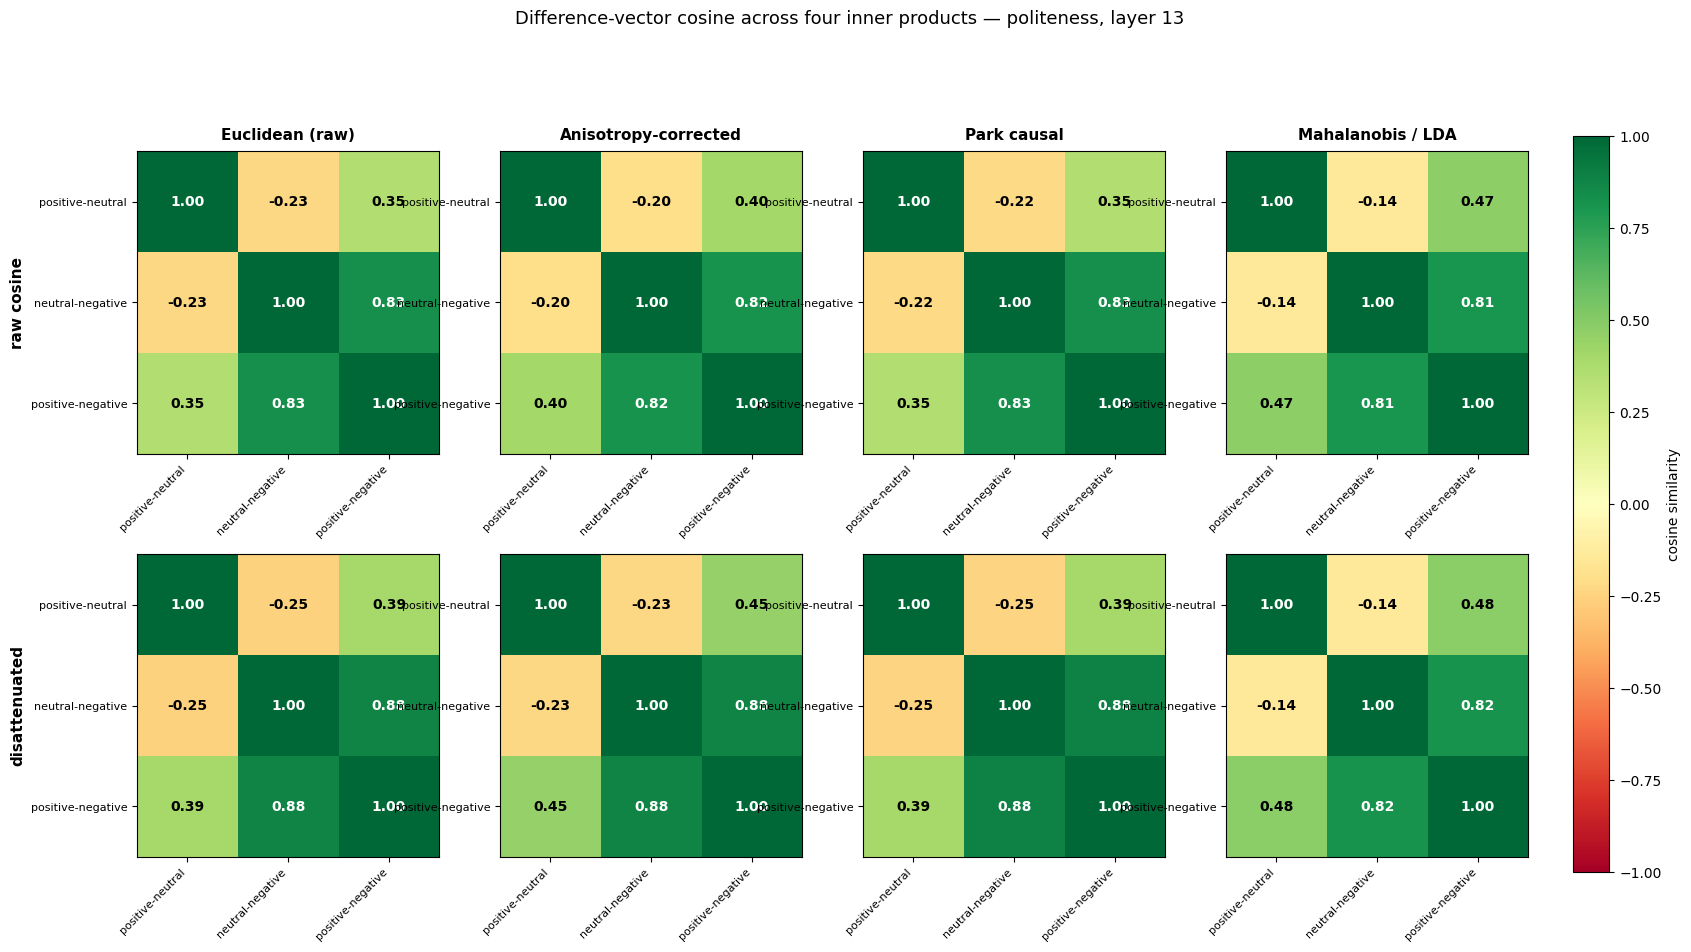

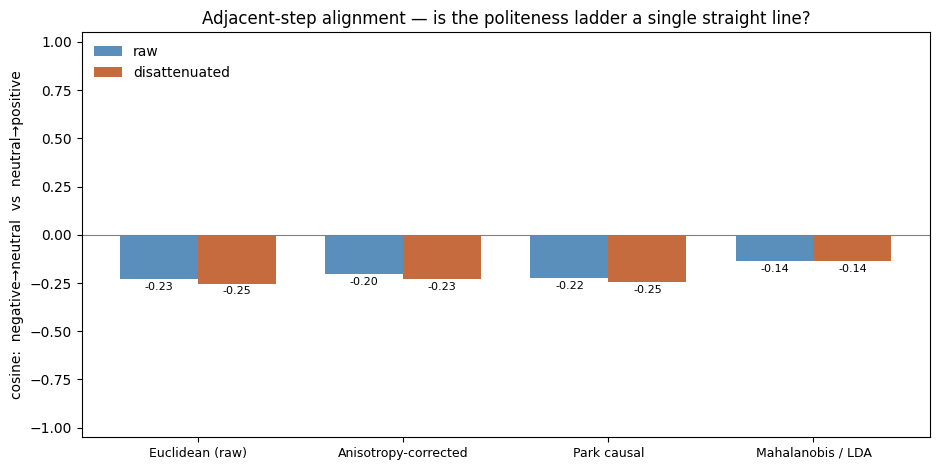

In [ ]:
# §3.5 — Visual comparison across the inner products
order = list(SPACES)
labels_S = space_results[order[0]]["labels"]
n = len(labels_S)

fig, axes = plt.subplots(2, len(order), figsize=(4.75 * len(order), 9.6))
for col, name in enumerate(order):
    r = space_results[name]
    for row, (mat, tag) in enumerate(
        [(r["cos_raw"], "raw cosine"), (r["cos_dis"], "disattenuated")]
    ):
        ax = axes[row, col]
        im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdYlGn")
        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        ax.set_xticklabels(labels_S, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(labels_S, fontsize=8)
        for i, j in itertools.product(range(n), range(n)):
            c = "white" if abs(mat[i, j]) > 0.65 else "black"
            ax.text(
                j,
                i,
                f"{mat[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color=c,
            )
        if row == 0:
            ax.set_title(name, fontsize=11, fontweight="bold", pad=8)
        if col == 0:
            ax.set_ylabel(tag, fontsize=11, fontweight="bold")
fig.colorbar(
    im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.03, label="cosine similarity"
)
fig.suptitle(
    f"Difference-vector cosine across four inner products — {TRAIT}, layer {LAYER}",
    fontsize=13,
    y=1.01,
)
plt.show()

# Focused comparison: the adjacent-step cosine, raw vs disattenuated.
raw_vals = [space_results[s]["cos_raw"][0, 1] for s in order]
dis_vals = [space_results[s]["cos_dis"][0, 1] for s in order]
x = np.arange(len(order))
bw = 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.8))
b1 = ax.bar(x - bw / 2, raw_vals, bw, label="raw", color="#5A8FBB")
b2 = ax.bar(x + bw / 2, dis_vals, bw, label="disattenuated", color="#C66B3D")
ax.bar_label(b1, fmt="%.2f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.2f", fontsize=8, padding=2)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=9)
ax.set_ylim(-1.05, 1.05)
ax.set_ylabel("cosine:  negative→neutral  vs  neutral→positive")
ax.set_title(
    "Adjacent-step alignment — is the politeness ladder a single straight line?"
)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

#### How to read §3.5

Focus on the off-diagonal **`negative→neutral` vs `neutral→positive`** entry — the adjacent-step cosine reported in §3.2 — and compare it across the five columns and between the **raw** (top) and **disattenuated** (bottom) rows. The bar chart isolates exactly this number.

- **Stays near 0 in all four spaces and survives disattenuation** → the near-orthogonality is a genuine geometric fact: the politeness ladder is *not* one straight line, no matter how angles are measured or how much noise is removed.
- **Jumps toward +1 under Park or Mahalanobis whitening** → the Euclidean value was an artifact of the raw-coordinate ruler; the steps *are* aligned once the space is measured in a model-appropriate (Park) or noise-aware (Mahalanobis) geometry.
- **Agrees between Mahalanobis and Within-subj noise** → the noise-aware conclusion is not an artifact of nuisance variance. The Within-subj column measures angles in units of the two-way residual (interaction + paraphrase noise) while *preserving* the politeness axis, so a value matching Mahalanobis confirms the latter's `Σ_within` was not merely absorbing between-scenario/-topic spread.
- **Disattenuation lifts it substantially** → the centroids were too noisy to resolve the alignment. The `R` columns in the table quantify this: `R ≈ 1` means a step vector is well-estimated, `R ≪ 1` means it is dominated by sampling noise — in which case *any* cosine involving it (here and in §3.2) is only a lower bound on the true alignment.

The Euclidean **disattenuated** value is the direct, noise-corrected successor to the §3.2 headline number; the other four columns then ask whether that conclusion is also robust to the choice of inner product.

### 3.6 Per-Scenario Alignment

§3.2 reports the cosine between *grand-mean* difference vectors pooled across all scenarios. The within-scenario differencing already cancels additive per-scenario offsets (topic, invariant content), but one residual issue remains — and the code below quantifies it.

**Per-scenario step cosine.** `per_scenario_step_cosines` computes, *inside each scenario*, the cosine between `(neutral − negative)` and `(positive − neutral)`, returning one value per complete scenario. Their histogram is compared against the §3.2 grand cosine-of-means: averaging many difference vectors before taking a cosine shrinks per-scenario noise, so the grand value can look aligned even when individual within-context transitions are not.

In [ ]:
# import random as _random
# from sklearn.datasets import fetch_20newsgroups
#
# WIKI_N = 60          # random text snippets to use as a null baseline
# WIKI_PAIRS = 200     # null cosine samples
# WIKI_SEED = 7
#
## 20 Newsgroups is sklearn-native (already a dep), ~14MB, cached after first call.
## We strip headers/footers/quotes so what's left is plain prose.
# _ds = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
# _rng = _random.Random(WIKI_SEED)
# _candidates = [t.strip().replace('\n', ' ') for t in _ds.data
#               if t and 20 <= len(t.split()) <= 200]
# _rng.shuffle(_candidates)
# wiki_texts = _candidates[:WIKI_N]
# print(f'fetched {len(wiki_texts)} text snippets')
# print('example:', wiki_texts[0][:140])

In [ ]:
# wiki_samples = [
#    Sample(prompt=t, trait='wiki', intensity='rand', scenario_id=f'wiki-{i:03d}')
#    for i, t in enumerate(wiki_texts)
# ]
# wiki_acts_dict = extract_activations(wiki_samples, model, tokenizer, [LAYER], device)
# wiki_vecs = [wiki_acts_dict[('wiki', 'rand', f'wiki-{i:03d}', LAYER)] for i in range(len(wiki_texts))]
# print(f'wiki activations: n={len(wiki_vecs)}, dim={tuple(wiki_vecs[0].shape)}')

In [ ]:
# from scipy.spatial.distance import cosine as _cos
#
# rng = _random.Random(WIKI_SEED)
# null_cosines = []
# for _ in range(WIKI_PAIRS):
#    a, b, c, d = rng.sample(range(len(wiki_vecs)), 4)
#    diff1 = (wiki_vecs[a] - wiki_vecs[b]).numpy()
#    diff2 = (wiki_vecs[c] - wiki_vecs[d]).numpy()
#    null_cosines.append(1.0 - _cos(diff1, diff2))
#
# null_arr = np.array(null_cosines)
# print(f'null cosine distribution (n={len(null_arr)}):')
# print(f'  mean={null_arr.mean():.4f}  std={null_arr.std():.4f}')
# print(f'  q05={np.quantile(null_arr, 0.05):.4f}  q95={np.quantile(null_arr, 0.95):.4f}  q99={np.quantile(null_arr, 0.99):.4f}')
#
# print('\nPoliteness off-diagonal cosines vs null:')
# for i in range(len(labels)):
#    for j in range(i + 1, len(labels)):
#        v = matrix[i, j]
#        p_emp = float((null_arr >= v).mean())
#        print(f'  {labels[i]:>22} vs {labels[j]:<22} cos={v:+.4f}  p(null>=obs)={p_emp:.4f}')

**Reading the plot:**
- Gray bars = null distribution (random pairs).
- Colored vertical lines = observed cosine for each transition pair.
- Lines to the far right of the histogram tail → alignment is statistically meaningful.
- Lines buried in the histogram bulk → indistinguishable from noise at that layer.

In [ ]:
# fig, ax = plt.subplots(figsize=(9, 4.4))
# ax.hist(null_arr, bins=40, color='lightgray', edgecolor='gray', label='Wikipedia null pairs')
# _colors = plt.cm.tab10(np.linspace(0, 1, 10))
# _k = 0
# for i in range(len(labels)):
#    for j in range(i + 1, len(labels)):
#        ax.axvline(matrix[i, j], color=_colors[_k % 10], linewidth=2,
#                   label=f'{labels[i]} vs {labels[j]}: {matrix[i, j]:+.2f}')
#        _k += 1
# ax.axvline(0, color='black', linewidth=0.7, linestyle=':')
# ax.set_xlabel('cosine similarity of difference vectors')
# ax.set_ylabel('count (null pairs)')
# ax.set_title(f'Politeness vs random-Wikipedia null distribution — layer {LAYER}')
# ax.legend(fontsize=8, loc='upper left')
# plt.tight_layout()
# plt.show()

## 5. Formal Linearity Metrics

Section 3 tested whether *centroids* fall on a line. This section tests whether the **full distribution** of individual sample activations is linearly ordered — a stricter requirement.

**Within-scenario estimation (each scenario is its own control).** The activations carry large nuisance variance that is independent of politeness: topic family and invariant content. Because each `scenario_id` fixes both, we treat each scenario as its own control and apply the within-scenario (fixed-effects) transform — subtracting each scenario's across-level mean — before measuring geometry. Every metric is reported in two forms:

- **within-scenario** — the trustworthy estimator: within-scenario transform, `GroupKFold` (a scenario's levels never split across train/test), an **out-of-fold** projection axis, and **per-scenario** distributions for the geometric metrics;
- **naive (pooled)** — the old estimator that pools all samples by level only, shown solely as a baseline to expose the confound's footprint.

| Metric | What it measures | Ideal |
|--------|-----------------|-------|
| **Spearman ρ / Kendall τ** | Rank agreement between each sample's out-of-fold projection onto the within-scenario `negative→positive` axis and its ordinal label. *(Structurally capped at ρ≈0.94, τ≈0.83 for three equal-size levels — not 1.)* | → ceiling |
| **Ridge R²** | Linear decodability of ordinal rank (GroupKFold CV) | → +1 |
| **Monotone fraction** | Share of scenarios whose three projections increase neg→neut→pos | → +1 |
| **Midpoint residual** | Per scenario: distance of `neutral` from the midpoint of `negative`/`positive`, normalised by span; reported as a distribution | → 0 |
| **PC1 fraction** | How 1-D each scenario's three-point geometry is, plus the pooled-centroid value | → +1 |

> **Why R² can be high while the adjacent-step cosine (§3) is near zero.** Probe R²/Spearman test whether the three clusters are *linearly separable*; the §3 cosine tests whether consecutive *transition directions* agree. A V-shape is perfectly separable (high R²) yet has orthogonal transitions (cosine ≈ 0) — the model can *order* the levels without placing them at equal steps along a single ray.


### Metric Functions

All metrics live in `lib.analysis` (imported in §1) and are unit-tested in `tests/test_analysis.py`. The within-scenario estimator `within_scenario_linearity_metrics(activations, levels, trait)` computes everything below; `ordinal_linearity_metrics` is the naive pooled baseline.

**Setup (shared by every within-scenario metric).**
1. `scenario_triples` keeps only scenarios that have all three levels → for each, a `(3, D)` matrix whose rows are the `negative / neutral / positive` activations (each already the mean over that cell's ≈3 paraphrases).
2. **Within-scenario transform** (`within_center`): subtract each scenario's mean-over-its-three-rows. This removes the scenario's additive offset (language, topic, invariant content), leaving only the politeness deviation. The rows are stacked into a design matrix `X` (one row per scenario × level), with labels `y ∈ {0,1,2}` and `groups = scenario id`.

**How each metric is computed.**
- **Ridge R²** — `cross_val_score(Ridge, X, y, cv=GroupKFold(5), groups)`. `GroupKFold` holds out *whole scenarios*, so a scenario's three rows never straddle train/test (the leakage a shuffled KFold allowed). Reported value = mean R² across folds.
- **Spearman ρ / Kendall τ** — *out-of-fold* projection. In each fold, the axis is the unit mean of `(positive − negative)` over the **training** scenarios; the held-out centered vectors are projected onto it to one scalar each. ρ/τ are then computed between every sample's out-of-fold scalar and its label `y`. *(With three equal-size ordinal levels these cap at ρ≈0.94, τ≈0.83 — a property of correlating a continuous projection with a 3-value label, not a ceiling on the model.)*
- **Monotone fraction** — project each scenario's three centered vectors onto one global axis (unit mean of `positive − negative` over **all** scenarios); the metric is the fraction of scenarios whose three scalars strictly increase `neg < neut < pos`.
- **Midpoint residual** *(per scenario)* — for each scenario, `‖neutral − ½(negative + positive)‖ / ‖positive − negative‖`. Reported as the **distribution** (median + IQR) over scenarios; 0 = neutral sits exactly halfway (uniform spacing), 1 = displaced by a full span.
- **PC1 fraction** *(per scenario)* — SVD of each scenario's three centered points, `σ₁² / (σ₁² + σ₂²)`. 1 = the three points are collinear. Reported as the per-scenario mean.
- **Pooled-centroid versions** (`midpoint_residual_pooled`, `pc1_frac_centroids`) — the same two formulas applied to the three *pooled* centroids (mean of the centered vectors per level). These reproduce the naive single-number geometry, kept for comparison; `pc1_frac_centroids` is also the label-sensitive statistic used in the §5.3 null.

**Naive baseline** `ordinal_linearity_metrics` differs deliberately: it pools all vectors by level (no scenario control), takes the projection axis *in-sample* from the pooled centroids, projects the *raw* (un-centered) vectors, and uses a shuffled `KFold` for the ridge probe — so any gap between within-scenario and naive measures the confound's footprint.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import spearmanr, kendalltau


def _per_level_arrays(acts_by_level, levels_ordered):
    X = np.stack([v.numpy() for lvl in levels_ordered for v in acts_by_level[lvl]])
    y = np.array(
        [r for r, lvl in enumerate(levels_ordered) for _ in acts_by_level[lvl]]
    )
    centroids = np.stack(
        [
            np.stack([v.numpy() for v in acts_by_level[lvl]]).mean(axis=0)
            for lvl in levels_ordered
        ]
    )
    return X, y, centroids


def ordinal_linearity_metrics(
    acts_by_level, levels_ordered, cv=5, ridge_alpha=1.0, seed=0
):
    """Spearman/Kendall, ridge probe R², midpoint residual, PC1 fraction."""
    X, y, centroids = _per_level_arrays(acts_by_level, levels_ordered)

    direction = centroids[-1] - centroids[0]
    direction = direction / np.linalg.norm(direction)
    scalar = X @ direction
    spearman = float(spearmanr(scalar, y).statistic)
    kendall = float(kendalltau(scalar, y).statistic)

    # Shuffled KFold — X is ordered by level, so an unshuffled split would put
    # only one class in each test fold (SS_tot = 0 → R² undefined → NaN).
    splitter = KFold(n_splits=cv, shuffle=True, random_state=seed)
    r2 = float(
        cross_val_score(
            Ridge(alpha=ridge_alpha), X, y, cv=splitter, scoring="r2"
        ).mean()
    )

    if len(levels_ordered) == 3:
        midpoint = (centroids[0] + centroids[-1]) / 2
        midpoint_residual = float(
            np.linalg.norm(centroids[1] - midpoint)
            / np.linalg.norm(centroids[-1] - centroids[0])
        )
    else:
        midpoint_residual = float("nan")

    centered = centroids - centroids.mean(axis=0, keepdims=True)
    s = np.linalg.svd(centered, compute_uv=False)
    pc1_frac = float((s[0] ** 2) / (s**2).sum())

    return {
        "spearman": spearman,
        "kendall": kendall,
        "probe_r2": r2,
        "midpoint_residual": midpoint_residual,
        "pc1_frac": pc1_frac,
    }


def acts_by_level_from_dict(acts_dict, levels):
    """Group (trait, intensity, scenario_id) -> tensor by intensity."""
    return {
        lvl: [v for (_, l, _), v in acts_dict.items() if l == lvl] for lvl in levels
    }

### 5.1 Metrics at Layer 13

`within_scenario_linearity_metrics` is run on the layer-13 activations and printed beside the naive `ordinal_linearity_metrics` baseline. The two histograms plot the **per-scenario** distributions that underlie the single-number geometry:
- *left* — midpoint residual per complete scenario; red line = median, dashed black = the naive pooled value;
- *right* — PC1 fraction per scenario; red line = median.

**Reading it:**
- **within-scenario vs naive gaps** flag confound sensitivity — the naive Spearman/probe collapse when per-scenario offsets dominate; the within-scenario values recover the within-context signal.
- **`probe_r2`** — within-scenario uses `GroupKFold` (no scenario leakage); the naive value uses shuffled folds and is optimistic.
- Read midpoint residual / PC1 from the **distribution**, not the single pooled number (printed only to show how far it sits from the per-context truth).

A high within-scenario Spearman/R² together with a per-scenario midpoint-residual distribution centred well above 0 is the signature of an *ordered-but-not-uniformly-spaced* encoding — now established *within* fixed language/topic/content, free of the pooling confound.

In [ ]:
abl_13 = acts_by_level_from_dict(activations, levels_present)
metrics_13 = ordinal_linearity_metrics(abl_13, levels_present)
print(f"Layer {LAYER} — ordinal linearity metrics:")
for k, v in metrics_13.items():
    print(f"  {k:>20}: {v:+.4f}")

Layer 13 — ordinal linearity metrics:
              spearman: +0.7750
               kendall: +0.6308
              probe_r2: +0.7693
     midpoint_residual: +0.6132
              pc1_frac: +0.7822


### 5.2 Centroid Geometry in PCA Space

Two views, both confound-aware; both start from the complete scenario triples stacked as `(S, 3, D)`.

**1 · Raw vs within-centered PCA.** Both panels project the level vectors to 2-D with PCA and overlay, per level, the individual samples (small dots), the level centroid in PC space (large outlined marker), and arrows `neg→neut→pos`; the axis titles give each PC's variance share. The panels differ *only* in what is fed to PCA.

- **Left — raw vectors.** Each activation ≈ a large *scenario baseline* (fixed by language, topic, and the invariant content, and shared by all three levels of that scenario) **plus** a small politeness shift. PCA ranks directions by variance, and the between-scenario baseline variance dwarfs the politeness shift — so PC1–PC2 capture *language / topic* and the three politeness levels land on top of one another.
- **Right — within-centered vectors.** Before PCA we subtract, from a scenario's three vectors, *their own mean* — `mats.mean(axis=1)`, i.e. that scenario's centroid over `{negative, neutral, positive}`. This sends every scenario's baseline to the origin, so the only variance left is the within-scenario movement from `negative` to `positive`. PCA then puts the politeness geometry on PC1 and the centroids separate along a clear axis.

**Why a per-scenario mean — doesn't PCA already center?** PCA removes only *one global* mean internally; that just recenters the whole cloud and does not change which directions carry the most variance. Subtracting a *different mean for each scenario* is what cancels the between-scenario baselines (the confound). It is exactly the within-scenario (fixed-effects) transform the §5 metrics use — so the right panel is the visual twin of those numbers. The only cost is one degree of freedom per scenario (each scenario's three centered vectors sum to zero), which is why the panel shows *relative* geometry, not absolute position.

**2 · Per-scenario grid.** A shared 2-D frame is built once: the **x-axis** is the unit mean `positive − negative` direction across scenarios (the average politeness axis); the **y-axis** is the top principal component of the centered residuals *after the x-axis component has been projected out* (the dominant orthogonal direction). For a language-balanced sample of scenarios, each scenario's three centered vectors are projected onto `(x, y)` and drawn with arrows. This lets you eyeball whether `neg→neut→pos` is monotone and evenly spaced *inside individual contexts* — the geometry the pooled scatter averages away.

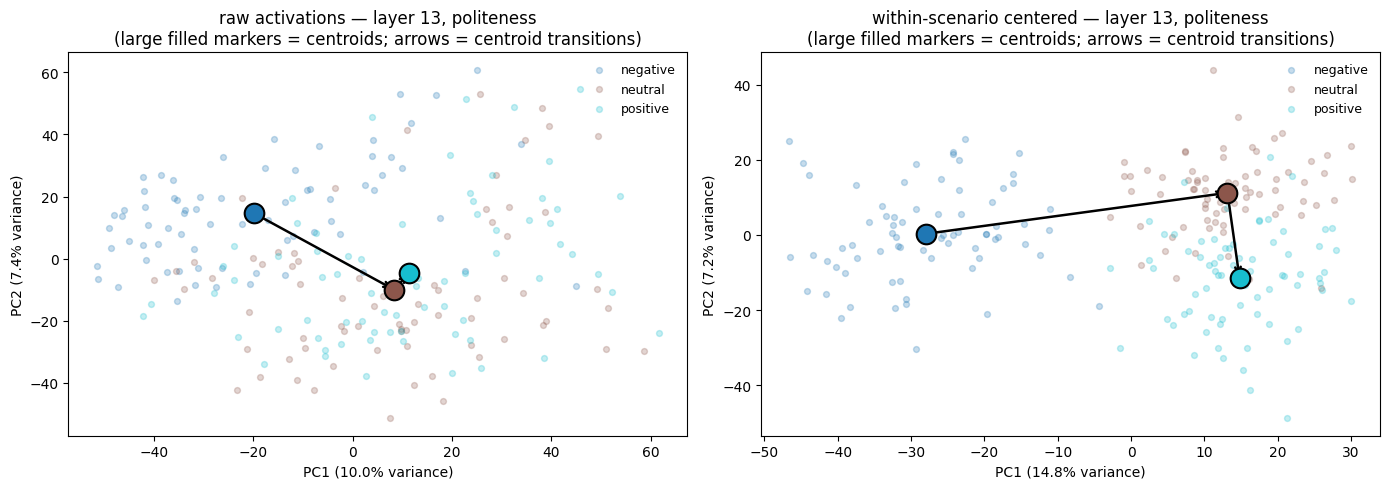

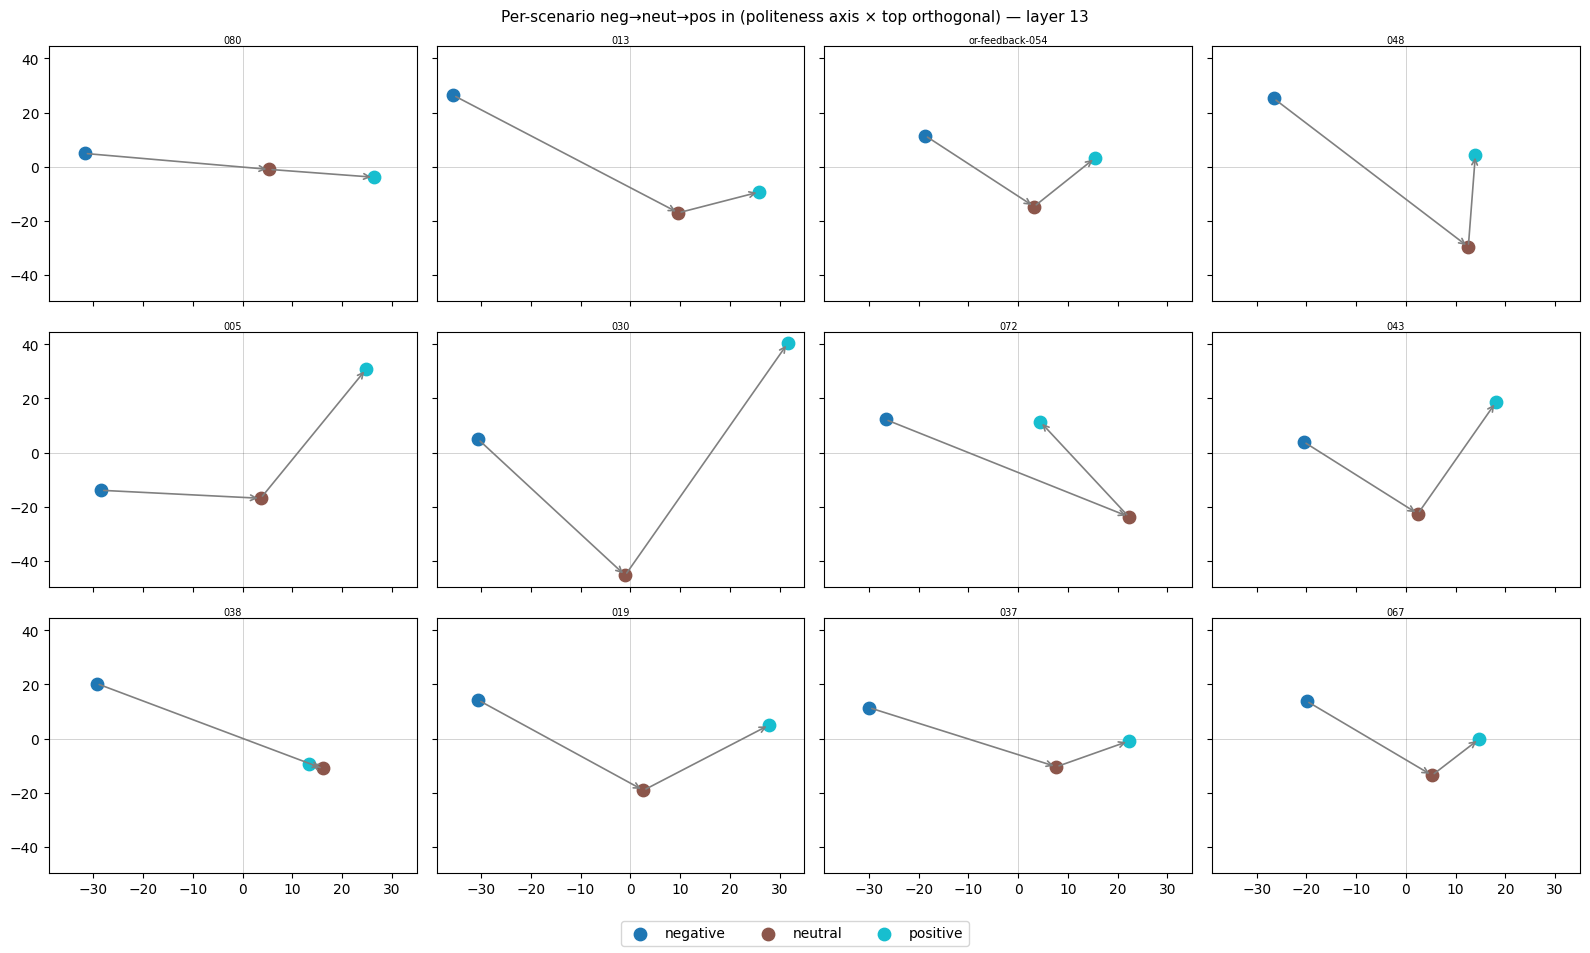

In [ ]:
from sklearn.decomposition import PCA

# --- Raw vs within-centered PCA: PC1 of raw activations is dominated by
#     scenario/topic; the within-scenario transform exposes the politeness axis. ---
triples = scenario_triples(activations, levels_present, trait=TRAIT)
sids = sorted(triples)
mats = np.stack([triples[s] for s in sids])              # (S, L, D)
L = len(levels_present)

raw_X = mats.reshape(len(sids) * L, -1)
cen_X = (mats - mats.mean(axis=1, keepdims=True)).reshape(len(sids) * L, -1)
_all_lbls = [levels_present[i % L] for i in range(len(sids) * L)]
_palette = [c for _, c in zip(levels_present, plt.cm.tab10(np.linspace(0, 1, L)))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (_X, title) in zip(axes, [(raw_X, "raw activations"), (cen_X, "within-scenario centered")]):
    pca = PCA(n_components=2)
    _coords = pca.fit_transform(_X)
    _var = pca.explained_variance_ratio_

    _centroids_2d = np.stack(
        [
            _coords[[i for i, l in enumerate(_all_lbls) if l == lvl]].mean(0)
            for lvl in levels_present
        ]
    )

    for k, lvl in enumerate(levels_present):
        _idx = [i for i, l in enumerate(_all_lbls) if l == lvl]
        ax.scatter(
            _coords[_idx, 0],
            _coords[_idx, 1],
            alpha=0.25,
            s=18,
            color=_palette[k],
            label=lvl,
        )
        ax.scatter(
            *_centroids_2d[k],
            s=200,
            color=_palette[k],
            edgecolors="black",
            linewidths=1.5,
            zorder=5,
        )

    for i in range(len(levels_present) - 1):
        ax.annotate(
            "",
            xy=_centroids_2d[i + 1],
            xytext=_centroids_2d[i],
            arrowprops=dict(arrowstyle="->", color="black", lw=1.8),
        )

    ax.set_xlabel(f"PC1 ({_var[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({_var[1]:.1%} variance)")
    ax.set_title(
        f"{title} — layer {LAYER}, {TRAIT}\n"
        f"(large filled markers = centroids; arrows = centroid transitions)"
    )
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# --- Per-scenario grid: each scenario's 3 levels in a shared (politeness axis x
#     orthogonal residual) plane, to eyeball within-context monotonicity/spacing. ---
centered = mats - mats.mean(axis=1, keepdims=True)                       # (S, L, D)
axis = (mats[:, -1] - mats[:, 0]).mean(0); axis /= np.linalg.norm(axis)  # mean within-scenario neg->pos
flat = centered.reshape(-1, centered.shape[-1])
flat_orth = flat - np.outer(flat @ axis, axis)                          # remove axis component
orth = PCA(n_components=1).fit(flat_orth).components_[0]                 # top orthogonal direction

rng = np.random.default_rng(0)
n_show = min(12, len(sids))
sample = list(rng.choice(sids, size=n_show, replace=False))

ncols = 4
nrows = (len(sample) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.2), sharex=True, sharey=True)
for idx, (ax, sid) in enumerate(zip(axes.flat, sample)):
    mat = triples[sid]                                    # (L, D)
    cen_mat = mat - mat.mean(axis=0, keepdims=True)       # within-scenario centered
    xs = cen_mat @ axis
    ys = cen_mat @ orth
    for k, lvl in enumerate(levels_present):
        ax.scatter(xs[k], ys[k], color=_palette[k], s=80, zorder=3,
                   label=lvl if idx == 0 else None)
    for i in range(L - 1):
        ax.annotate("", xy=(xs[i + 1], ys[i + 1]), xytext=(xs[i], ys[i]),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.2))
    ax.set_title(sid.split("-", 2)[-1], fontsize=7, pad=2)
    ax.axhline(0, color="k", lw=0.4, alpha=0.3)
    ax.axvline(0, color="k", lw=0.4, alpha=0.3)

for ax in axes.flat[len(sample):]:
    ax.set_visible(False)

handles, label_legend = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, label_legend, loc="lower center", ncol=L, fontsize=10)
fig.suptitle(
    f"Per-scenario neg\u2192neut\u2192pos in (politeness axis \u00d7 top orthogonal) \u2014 layer {LAYER}",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


### 5.3 Within-Scenario Permutation Null

**What the code does.** For each of `N_PERM` iterations it permutes — *inside every scenario independently* — which of the three vectors is labelled `negative / neutral / positive`, then recomputes the within-scenario metrics. This builds a null distribution for "the activations carry no politeness order," while scenario/topic structure is held fixed. (A global shuffle would also destroy that structure, testing a weaker hypothesis.)

**p-values.** Reported as the Monte-Carlo permutation p-value `p = (1 + #{null at least as extreme as obs}) / (1 + N_PERM)`. The add-one form counts the observed labelling as one valid permutation, so p can never be exactly 0 — its floor is `1/(N_PERM+1)` (raise `N_PERM` to tighten the bound). The tail is one-sided in the favourable direction: `null ≥ obs` for ρ / τ / R² / monotone fraction / PC1, and `null ≤ obs` for midpoint residual (lower = more linear). A red line far outside the gray null bulk ⇒ the within-context structure is real. Six metrics are tested, so treat p-values near the floor as a family — apply a Bonferroni/FDR adjustment if a single decisive claim is needed.

*(PC1 is tested via the pooled-centroid value `pc1_frac_centroids`, not the per-scenario mean: a within-scenario label permutation leaves each scenario's unordered triple — and hence its per-scenario PC1 — unchanged, giving a degenerate null.)*

Within-scenario label-permutation null (n=100) vs observed at layer 13:
(Monte-Carlo permutation p = (1 + #{null beyond obs}) / (1 + n);  floor = 0.0099)
                    spearman: obs=+0.8414  null μ=-0.0060 σ=0.1225  p(null>=obs)=0.0099
                     kendall: obs=+0.7010  null μ=-0.0047 σ=0.0944  p(null>=obs)=0.0099
                    probe_r2: obs=+0.8533  null μ=-0.3881 σ=0.1719  p(null>=obs)=0.0099
           monotone_fraction: obs=+0.8056  null μ=+0.3451 σ=0.0676  p(null>=obs)=0.0099
    midpoint_residual_median: obs=+0.7169  null μ=+0.8444 σ=0.0260  p(null<=obs)=0.0099
          pc1_frac_centroids: obs=+0.7822  null μ=+0.5996 σ=0.0536  p(null>=obs)=0.0099


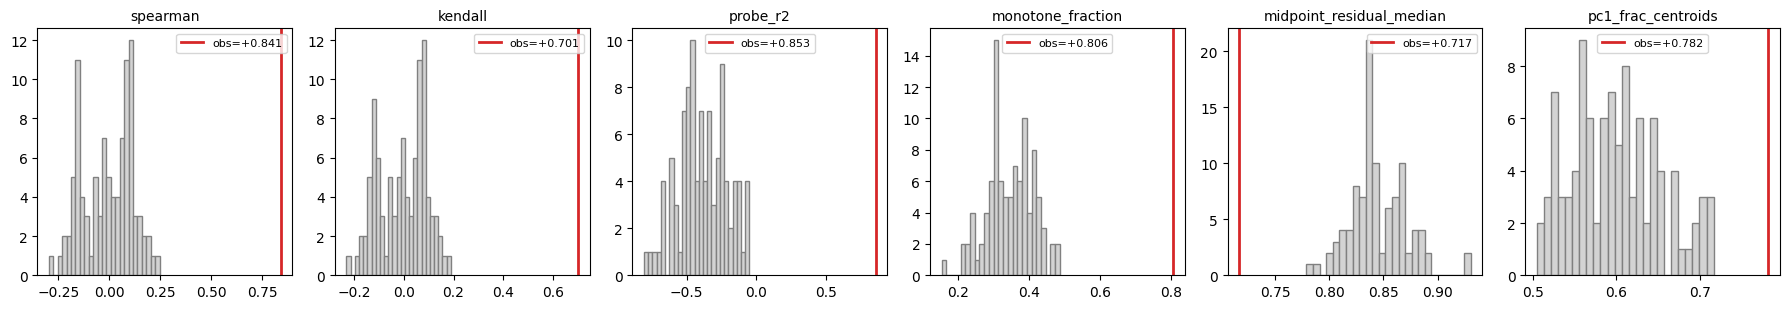

In [ ]:
N_PERM = 100
PERM_SEED = 13
_rng = np.random.default_rng(PERM_SEED)

# Within-scenario label permutation: shuffle the level labels INSIDE each
# scenario. This preserves scenario/topic structure and isolates the
# politeness null (a global shuffle would also destroy those factors).
triples = scenario_triples(activations, levels_present, trait=TRAIT)
obs = within_scenario_linearity_metrics(activations, levels_present, trait=TRAIT)

test_keys = ["spearman", "kendall", "probe_r2", "monotone_fraction",
             "midpoint_residual_median", "pc1_frac_centroids"]
# Lower-is-more-linear metrics use the left tail; the rest use the right tail.
lower_tail = {"midpoint_residual_median"}
null = {k: [] for k in test_keys}
for _ in range(N_PERM):
    perm_acts = {}
    for sid, mat in triples.items():
        order = _rng.permutation(len(levels_present))
        for i, lvl in enumerate(levels_present):
            perm_acts[(TRAIT, lvl, sid)] = mat[order[i]]
    m = within_scenario_linearity_metrics(perm_acts, levels_present, trait=TRAIT)
    for k in test_keys:
        null[k].append(m[k])
null = {k: np.array(v) for k, v in null.items()}

print(f"Within-scenario label-permutation null (n={N_PERM}) vs observed at layer {LAYER}:")
print(f"(Monte-Carlo permutation p = (1 + #{{null beyond obs}}) / (1 + n);  floor = {1 / (1 + N_PERM):.4f})")
for k in test_keys:
    obs_val = obs[k]
    if np.isnan(obs_val):
        print(f"  {k:>26}: n/a")
        continue
    if k in lower_tail:
        p = float((1 + (null[k] <= obs_val).sum()) / (1 + N_PERM))
        tail = "<="
    else:
        p = float((1 + (null[k] >= obs_val).sum()) / (1 + N_PERM))
        tail = ">="
    print(
        f"  {k:>26}: obs={obs_val:+.4f}  null μ={null[k].mean():+.4f} σ={null[k].std():.4f}  "
        f"p(null{tail}obs)={p:.4f}"
    )

fig, axes = plt.subplots(1, len(test_keys), figsize=(18, 3.2))
for ax, k in zip(axes, test_keys):
    obs_val = obs[k]
    if np.isnan(obs_val):
        ax.set_title(f"{k}\n(n/a)")
        ax.axis("off")
        continue
    ax.hist(null[k], bins=25, color="lightgray", edgecolor="gray")
    ax.axvline(obs_val, color="C3", linewidth=2, label=f"obs={obs_val:+.3f}")
    ax.set_title(k, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.4 Metrics Across Layers

`within_scenario_linearity_metrics` is recomputed at every swept layer (slicing the cached multilayer activations from §3.4), and the six metrics are plotted against layer. On the **midpoint-residual** and **PC1-fraction** panels the shaded band is the **per-scenario IQR** (25th–75th percentile) at each layer, so each trend is read against within-context spread rather than a single pooled point. The gray dotted line marks the focal layer 13; peaks or plateaus locate where intensity is most cleanly linearly encoded.

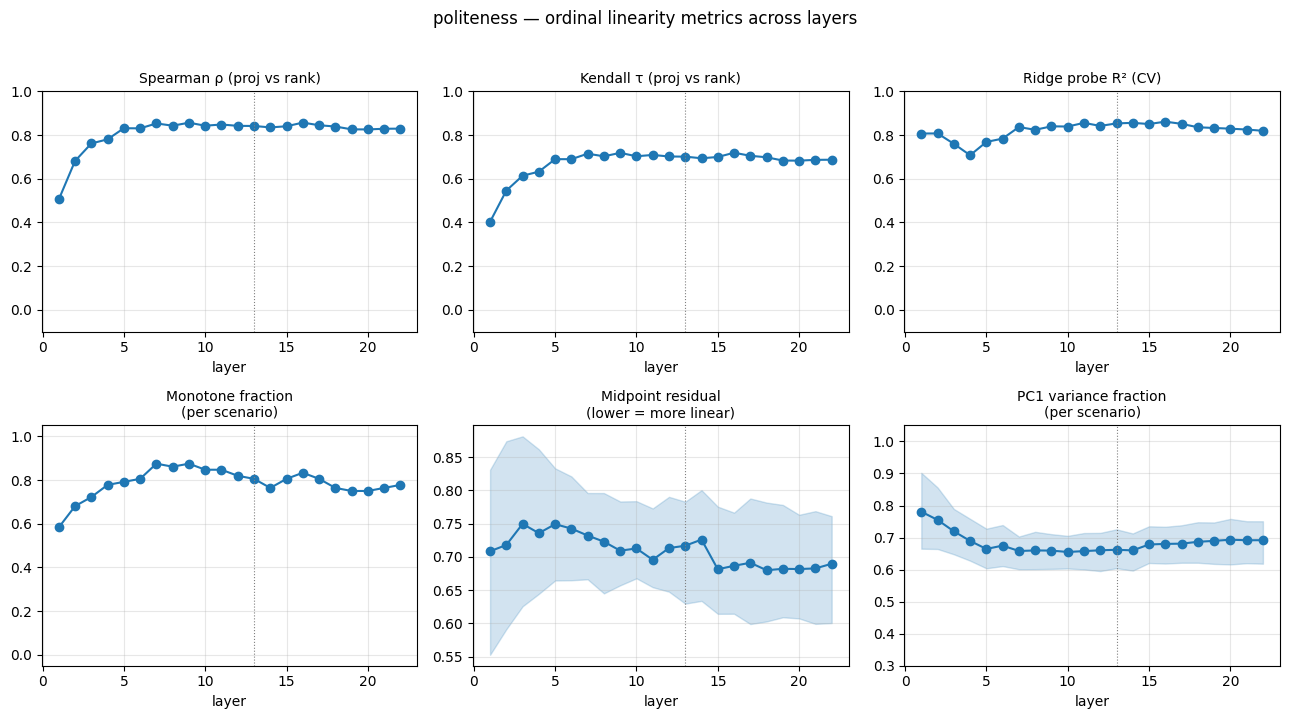

In [ ]:
sweep_keys = ["spearman", "kendall", "probe_r2", "monotone_fraction",
              "midpoint_residual_median", "pc1_frac_per_scenario_mean"]
sweep_results = {k: [] for k in sweep_keys}
midres_band = []   # (q25, q75) of per-scenario midpoint residual per layer
pc1_band = []
for layer in sweep_layers:
    acts_layer = {(t, i, s): v for (t, i, s, l), v in acts_all.items() if l == layer}
    m = within_scenario_linearity_metrics(acts_layer, levels_present, trait=TRAIT)
    for k in sweep_keys:
        sweep_results[k].append(m[k])
    mr = m["midpoint_residual_per_scenario"]; pc = m["pc1_frac_per_scenario"]
    midres_band.append((np.nanpercentile(mr, 25), np.nanpercentile(mr, 75)))
    pc1_band.append((np.percentile(pc, 25), np.percentile(pc, 75)))
midres_band = np.array(midres_band); pc1_band = np.array(pc1_band)

# (key, title, ylim, IQR band) -- band shades the per-scenario 25-75 percentile.
panel_info = [
    ("spearman", "Spearman ρ (proj vs rank)", (-0.1, 1.0), None),
    ("kendall", "Kendall τ (proj vs rank)", (-0.1, 1.0), None),
    ("probe_r2", "Ridge probe R² (CV)", (-0.1, 1.0), None),
    ("monotone_fraction", "Monotone fraction\n(per scenario)", (-0.05, 1.05), None),
    ("midpoint_residual_median", "Midpoint residual\n(lower = more linear)", None, midres_band),
    ("pc1_frac_per_scenario_mean", "PC1 variance fraction\n(per scenario)", (0.3, 1.05), pc1_band),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (key, title, ylim, band) in zip(axes.flat, panel_info):
    ax.plot(sweep_layers, sweep_results[key], marker="o", linewidth=1.5)
    if band is not None:
        ax.fill_between(sweep_layers, band[:, 0], band[:, 1], alpha=0.2, color="C0")
    ax.axvline(LAYER, color="gray", linestyle=":", linewidth=0.8)
    ax.set_xlabel("layer")
    ax.set_title(title, fontsize=10)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)
fig.suptitle(f"{TRAIT} — ordinal linearity metrics across layers", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### 5.5 Lexical Baseline (Bag-of-Words Control)

The metrics above measure structure in *activation* space. This control measures how much of the
level is recoverable from **surface lexicon alone**: a bag-of-words (1–2 gram) logistic regression
predicting the level from raw text, scored by stratified cross-validation. It is the honest baseline
the activation probe must beat — politeness is intrinsically lexical, so a non-trivial score is
expected; what matters is the *gap* between this and the representation-space separability. Runs
model-free on `accepted.jsonl`. (Salvaged from the old generation-time `audit()`; it belongs here,
beside the probe it is the baseline for, not in the generator.)

In [ ]:
import collections
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score

samples = load_accepted(ACCEPTED_JSONL)  # same TIMESTAMP as the representations above
lex_texts = [s.prompt for s in samples]
lex_levels = [s.intensity for s in samples]
n_classes = len(set(lex_levels))

vec = CountVectorizer(ngram_range=(1, 2), min_df=2)
X_lex = vec.fit_transform(lex_texts)
clf = LogisticRegression(max_iter=2000)
n_splits = min(5, min(collections.Counter(lex_levels).values()))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=7)
lex_preds = cross_val_predict(clf, X_lex, lex_levels, cv=cv)
lex_acc = accuracy_score(lex_levels, lex_preds)
print(
    f"Bag-of-words lexical baseline: {lex_acc:.3f}  (chance = {1 / n_classes:.3f}, n={len(lex_texts)})"
)

# Top discriminative n-grams per level
clf.fit(X_lex, lex_levels)
vocab = np.array(vec.get_feature_names_out())
coefs = clf.coef_
if coefs.shape[0] == 1:  # binary edge case
    coefs = np.vstack([-coefs[0], coefs[0]])
for idx, lvl in enumerate(clf.classes_):
    top = vocab[np.argsort(coefs[idx])[-10:][::-1]]
    print(f"  {lvl:9s}: {', '.join(top)}")

Bag-of-words lexical baseline: 0.850  (chance = 0.333, n=633)
  negative : now, what, immediately, don, no, late, wrong, seriously, even, not
  neutral  : please, full, needs, later, should, have, as, scheduled, soon, for
  positive : but, perhaps, if, we, appreciate, very, hope, at, might, thanks
